In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cardekho.csv to cardekho.csv


In [5]:
data = pd.read_csv("cardekho.csv")
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [6]:
data['mileage(km/ltr/kg)'] = data['mileage(km/ltr/kg)'].astype(str).str.split().str[0]
data['mileage(km/ltr/kg)'] = pd.to_numeric(data['mileage(km/ltr/kg)'], errors='coerce')

data['engine'] = data['engine'].astype(str).str.split().str[0]
data['engine'] = pd.to_numeric(data['engine'], errors='coerce')

data['max_power'] = data['max_power'].astype(str).str.split().str[0]
data['max_power'] = pd.to_numeric(data['max_power'], errors='coerce')

data = data.dropna()

In [7]:
X = data[['year','km_driven','mileage(km/ltr/kg)','engine','max_power','seats']]
Y = data['selling_price']

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

In [10]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, Y_train)

KNeighborsRegressor()

In [11]:
Y_pred = knn.predict(X_test)

print(Y_pred[:10])

[469000.  526000.  187600.  338000.  650000.  289000.  509999.8 151000.
 118200.  334000. ]


In [12]:
score = r2_score(Y_test, Y_pred)

print("R2 Score:", score)

R2 Score: 0.9625505363491449


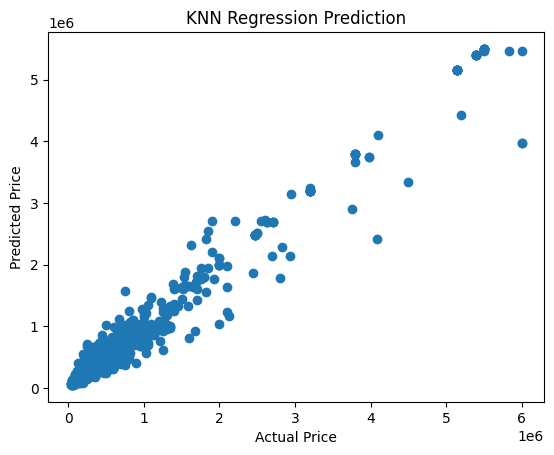

In [13]:
plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("KNN Regression Prediction")

plt.show()